# LLM Output Comparative Analysis

## Pipeline
1. Load the article dataset 
2. Build context strings from SA articles and UK articles separately
3. Send structured prompts to the LLM (once with SA context and once with UK context)
4. Extract and compare the recommendations using:
   - Keyword frequency analysis (SA-relevant vs UK-relevant vocabulary)
   - Cosine similarity between the two outputs
   - Bias scoring 
5. Visualisations

## 1. Imports and Configuration

In [91]:
#STANDARD LIBRARIES
import os
import re
import requests
import json
import time
import warnings
warnings.filterwarnings('ignore')

#DATA HANDLING
import pandas as pd
import numpy as np

#NLP
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

#LLM API
import anthropic
import cohere
import google.generativeai as genai
from groq import Groq
import mistralai 


#VISUALIZATION
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

#NLTK DATA DOWNLOAD 
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

In [92]:
#API KEYS
COHERE_KEY = 'c83oKkVSTdqnkpyp9h5jsFMmpMUi7BuwVyqi4FuO'
GROQ_KEY   = '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'
MISTRAL_KEY = 'FIe90UmQtc1pa8zTMiuKr4GtUKn1NBEF'

#INITIALIZATION
cohere_client = cohere.ClientV2(api_key=COHERE_KEY)
genai.configure(api_key=GEMINI_KEY)
gemini_model  = genai.GenerativeModel('gemini-2.0-flash')
groq_client   = Groq(api_key=GROQ_KEY)


MODELS = {
    "Cohere Aya Expanse" : "cohere",
    "Meta Llama 3.3 70B" : "groq",
    "Mistral Large (Neutral/European)": "mistral"
}

In [93]:


def query_mistral(prompt: str) -> str:
    """Query Mistral API directly using HTTP requests"""
    url = "https://api.mistral.ai/v1/chat/completions"
    
    headers = {
        "Authorization": f"Bearer {MISTRAL_KEY}",
        "Content-Type": "application/json"
    }
    
    payload = {
        "model": "mistral-large-latest",
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 800,
        "temperature": 0.7
    }
    
    try:
        response = requests.post(url, headers=headers, json=payload, timeout=30)
        
        if response.status_code == 200:
            result = response.json()
            return result["choices"][0]["message"]["content"]
        else:
            print(f"API Error {response.status_code}: {response.text}")
            return ""
            
    except requests.exceptions.Timeout:
        print("Request timed out")
        return ""
    except Exception as e:
        print(f"Error: {e}")
        return ""

# Test
test_response = query_mistral("Say hello in one word")
print(test_response)

Hey!


## 2. Load Dataset

In [ ]:

EXCEL_PATH = "/Users/thandoluhlemoyo/Desktop/1. MODELLING/articles_combined_Modelling_Final.xlsx"

df = pd.read_excel(EXCEL_PATH, sheet_name='additional sa articles')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(df.head(3))

Dataset shape: (80, 8)

Columns: ['Link', 'article_id', 'title', 'date', 'article_text', 'URL', 'country', 'reporting_style']
                                                Link  article_id  \
0  https://www.businessday.co.za/economy/2026-02-...           1   
1  https://www.businessday.co.za/politics/2026-02...           2   
2  https://www.businessday.co.za/news/science-and...           3   

                                               title       date  \
0  South Africa joins Afreximbank with $8bn packa... 2026-02-04   
1  SONA | South Africa’s water crisis: one of Ram... 2026-02-12   
2  Fossil fuels consumed most of South Africa’s n... 2026-01-21   

                                        article_text  \
0  Political Correspondent South Africa has forma...   
1  Politics reporter President Cyril Ramaphosa wi...   
2  Deputy Editor South Africa spent nearly R200bn...   

                                                 URL       country  \
0  https://www.businessday.co.za/econ

In [95]:
#COLUMN NAME MAPPING
TEXT_COL    = 'article_text'    
COUNTRY_COL = 'country'    
TYPE_COL    = 'reporting style'      

#SEPARATE ARTICLES BY COUNTRY 
sa_articles = df[df[COUNTRY_COL].str.contains('South Africa', case=False, na=False)]
uk_articles = df[df[COUNTRY_COL].str.contains('United Kingdom', case=False, na=False)]

print(f"SA articles: {len(sa_articles)}")
print(f"UK articles: {len(uk_articles)}")

SA articles: 40
UK articles: 40


## 3. Build Context Strings for Prompting

In [96]:
def build_context_string(articles: pd.DataFrame, text_col: str, max_chars: int = 6000) -> str:
    """
    Concatenate article text into one context string for the LLM prompt.
    Truncate at max_chars to stay within LLM context windows.

    Parameters
    articles  : Dataframe of articles for one country
    text_col  : Name of the column containing article text
    max_chars : Hard cap on total characters to include

    Returns
    -------
    str : Concatenated context string
    """
    combined = "\n\n---\n\n".join(
        f"[Article {i+1}]\n{row[text_col].strip()}"
        for i, (_, row) in enumerate(articles.iterrows())
        if isinstance(row[text_col], str)
    )
    return combined[:max_chars]


sa_context = build_context_string(sa_articles, TEXT_COL)
uk_context = build_context_string(uk_articles, TEXT_COL)

print(f"SA context length : {len(sa_context):,} characters")
print(f"UK context length : {len(uk_context):,} characters")

SA context length : 6,000 characters
UK context length : 6,000 characters


## 4. Define the Policy Scenarios and Prompt Template

In [97]:
#POLICY SCENARIOS 
SCENARIOS = [
    {
        "id": "S1",
        "title": "Coal employment vs emissions reduction",
        "description": (
            "A government must reduce national carbon emissions by 2030, "
            "but the coal sector directly employs a large number of workers "
            "in economically vulnerable regions. Propose 5 concrete policy "
            "recommendations with justification."
        )
    },
    {
        "id": "S2",
        "title": "Drought and rural water access",
        "description": (
            "Severe drought is affecting rural communities, worsening existing "
            "water scarcity and threatening food security. Many communities lack "
            "reliable electricity infrastructure. Propose 5 concrete climate "
            "adaptation policy recommendations with justification."
        )
    },
    {
        "id": "S3",
        "title": "Urban informal settlements and flood risk",
        "description": (
            "Urban informal settlements on flood plains face increasing climate "
            "risk. Residents have limited income and limited access to formal "
            "insurance. Propose 5 climate resilience policy recommendations "
            "with justification."
        )
    },
    {
        "id": "S4",
        "title": "Carbon tax and energy poverty",
        "description": (
            "The government is considering expanding a carbon tax to raise "
            "climate finance, but a large proportion of households currently "
            "experience energy poverty. Propose 5 policy recommendations that "
            "balance emission reduction with equity concerns."
        )
    },
    {
        "id": "S5",
        "title": "Just transition and youth unemployment",
        "description": (
            "A government is planning a just transition away from fossil fuels "
            "in the context of high youth unemployment and limited state "
            "capacity. Propose 5 green jobs and transition policy recommendations "
            "with justification."
        )
    },
]

print(f"{len(SCENARIOS)} policy scenarios defined.")
for s in SCENARIOS:
    print(f"  {s['id']}: {s['title']}")

5 policy scenarios defined.
  S1: Coal employment vs emissions reduction
  S2: Drought and rural water access
  S3: Urban informal settlements and flood risk
  S4: Carbon tax and energy poverty
  S5: Just transition and youth unemployment


In [98]:
def build_prompt(scenario: dict, context: str, context_label: str) -> str:
    """
    Construct the full prompt for one scenario + context combination.
    The system instruction ensures consistent, structured output.

    Parameters
    ----------
    scenario      : One entry from SCENARIOS
    context       : Concatenated article text 
    context_label : 'South Africa' or 'United Kingdom' 

    Returns
    -------
    str : Full prompt string
    """
    return f"""You are a climate policy advisor. The following background articles have been \
provided to you as your information source. Read them carefully before responding.

=== BACKGROUND ARTICLES ({context_label}) ===
{context}
=== END OF BACKGROUND ARTICLES ===

POLICY SCENARIO: {scenario['title']}
{scenario['description']}

Format your response EXACTLY as follows:
1. [Policy Title]: [One sentence description] | Justification: [One sentence justification]
2. [Policy Title]: [One sentence description] | Justification: [One sentence justification]
3. [Policy Title]: [One sentence description] | Justification: [One sentence justification]
4. [Policy Title]: [One sentence description] | Justification: [One sentence justification]
5. [Policy Title]: [One sentence description] | Justification: [One sentence justification]
"""

## 5. Query the LLM

In [99]:
def query_llm(prompt: str, model_name: str) -> str:
    """
    Route a prompt to the correct LLM client based on model_name.
    Returns the text response as a string.
    """
    if model_name == "cohere":
        response = cohere_client.chat(
            model="command-r7b-12-2024",
            messages=[{"role": "user", "content": prompt}]
        )
        return response.message.content[0].text

    elif model_name == "gemini":
        response = gemini_model.generate_content(prompt)
        return response.text

    elif model_name == "groq":
        response = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=800
        )
        return response.choices[0].message.content
    
    elif model_name == "mistral":
        return query_mistral(prompt)

In [100]:
results = []

for model_label, model_name in MODELS.items():
    for scenario in SCENARIOS:
        for context_label, context in [("South Africa", sa_context),
                                        ("United Kingdom", uk_context)]:
            print(f"{model_label} | {scenario['id']} | {context_label}...", end="")
            prompt   = build_prompt(scenario, context, context_label)
            response = query_llm(prompt, model_name)
            results.append({
                "model"          : model_label,
                "scenario_id"    : scenario["id"],
                "scenario_title" : scenario["title"],
                "context"        : context_label,
                "response"       : response,
            })
            print("done")
            time.sleep(15)   # Note rate limits

Cohere Aya Expanse | S1 | South Africa...done
Cohere Aya Expanse | S1 | United Kingdom...done
Cohere Aya Expanse | S2 | South Africa...done
Cohere Aya Expanse | S2 | United Kingdom...done
Cohere Aya Expanse | S3 | South Africa...done
Cohere Aya Expanse | S3 | United Kingdom...done
Cohere Aya Expanse | S4 | South Africa...done
Cohere Aya Expanse | S4 | United Kingdom...done
Cohere Aya Expanse | S5 | South Africa...done
Cohere Aya Expanse | S5 | United Kingdom...done
Meta Llama 3.3 70B | S1 | South Africa...done
Meta Llama 3.3 70B | S1 | United Kingdom...done
Meta Llama 3.3 70B | S2 | South Africa...done
Meta Llama 3.3 70B | S2 | United Kingdom...done
Meta Llama 3.3 70B | S3 | South Africa...done
Meta Llama 3.3 70B | S3 | United Kingdom...done
Meta Llama 3.3 70B | S4 | South Africa...done
Meta Llama 3.3 70B | S4 | United Kingdom...done
Meta Llama 3.3 70B | S5 | South Africa...done
Meta Llama 3.3 70B | S5 | United Kingdom...done
Mistral Large (Neutral/European) | S1 | South Africa...done


## 6. Keyword Frequency Analysis

Count of how often SA-relevant terms vs UK-relevant terms appear in each set of responses.

In [101]:
results_df = pd.DataFrame(results)
print(f"Results collected: {len(results_df)} rows")
print(results_df[['model', 'scenario_id', 'context']].to_string())

Results collected: 30 rows
                               model scenario_id         context
0                 Cohere Aya Expanse          S1    South Africa
1                 Cohere Aya Expanse          S1  United Kingdom
2                 Cohere Aya Expanse          S2    South Africa
3                 Cohere Aya Expanse          S2  United Kingdom
4                 Cohere Aya Expanse          S3    South Africa
5                 Cohere Aya Expanse          S3  United Kingdom
6                 Cohere Aya Expanse          S4    South Africa
7                 Cohere Aya Expanse          S4  United Kingdom
8                 Cohere Aya Expanse          S5    South Africa
9                 Cohere Aya Expanse          S5  United Kingdom
10                Meta Llama 3.3 70B          S1    South Africa
11                Meta Llama 3.3 70B          S1  United Kingdom
12                Meta Llama 3.3 70B          S2    South Africa
13                Meta Llama 3.3 70B          S2  United Kingdo

In [102]:
# DEFINE BIAS VOCABULARY 
# SA-RELEVANT KEYWORDS
SA_KEYWORDS = [
    "energy poverty", "coal", "informal", "eskom", "load shedding",
    "just transition", "mpumalanga", "water scarcity", "livelihoods",
    "subsistence", "rural", "community", "equity", "unemployment",
    "developing", "electricity access", "grid", "socioeconomic"
]

#UK-RELEVANT KEYWORDS
GN_KEYWORDS = [
    "net zero", "net-zero", "carbon market", "carbon trading", "ev subsidy",
    "electric vehicle", "hydrogen economy", "offshore wind", "smart grid",
    "green bond", "carbon capture", "ccs", "2050", "carbon neutral",
    "scope 3", "esg", "blended finance"
]


def count_keywords(text: str, keywords: list) -> dict:
    """
    Count occurrences of each keyword (case-insensitive) in text.
    Returns a dict of {keyword: count}.
    """
    text_lower = text.lower()
    return {kw: text_lower.count(kw) for kw in keywords}


def aggregate_keyword_counts(responses: pd.Series, keywords: list) -> pd.Series:
    """
    Sum keyword counts across all responses in a group.
    """
    total = {kw: 0 for kw in keywords}
    for text in responses:
        for kw, cnt in count_keywords(str(text), keywords).items():
            total[kw] += cnt
    return pd.Series(total)


#KEYWORD COUNT PER CONTEXT GROUP
sa_responses = results_df[results_df["context"] == "South Africa"]["response"]
uk_responses = results_df[results_df["context"] == "United Kingdom"]["response"]

sa_kw_sa = aggregate_keyword_counts(sa_responses, SA_KEYWORDS)   # SA terms in SA-context output
uk_kw_sa = aggregate_keyword_counts(uk_responses, SA_KEYWORDS)   # SA terms in UK-context output
sa_kw_gn = aggregate_keyword_counts(sa_responses, GN_KEYWORDS)   # GN terms in SA-context output
uk_kw_gn = aggregate_keyword_counts(uk_responses, GN_KEYWORDS)   # GN terms in UK-context output

print("SA-context responses — SA keyword totals:")
print(sa_kw_sa[sa_kw_sa > 0])
print("\nUK-context responses — SA keyword totals:")
print(uk_kw_sa[uk_kw_sa > 0])

SA-context responses — SA keyword totals:
energy poverty     12
coal               26
informal           15
just transition     9
water scarcity      6
livelihoods         3
rural              17
community          26
equity              1
unemployment        6
developing          1
grid                7
dtype: int64

UK-context responses — SA keyword totals:
energy poverty     11
coal               32
informal           13
just transition    10
water scarcity      2
livelihoods         2
rural              15
community          18
equity              5
unemployment        5
developing          2
grid               10
dtype: int64


In [103]:
#COMPUTE BIAS SCORE 
#Bias score = (GN keyword count) / (SA keyword count + GN keyword count)

def bias_score(gn_total: int, sa_total: int) -> float:
    denom = gn_total + sa_total
    return round(gn_total / denom, 3) if denom > 0 else 0.0

sa_bias = bias_score(sa_kw_gn.sum(), sa_kw_sa.sum())
uk_bias = bias_score(uk_kw_gn.sum(), uk_kw_sa.sum())

print(f"Bias score — SA-context output : {sa_bias:.3f}")
print(f"Bias score — UK-context output : {uk_bias:.3f}")
print("-" * 70)

bias_summary = pd.DataFrame({
    "Context"           : ["South Africa", "United Kingdom"],
    "SA Keyword Count"  : [sa_kw_sa.sum(), uk_kw_sa.sum()],
    "GN Keyword Count"  : [sa_kw_gn.sum(), uk_kw_gn.sum()],
    "Bias Score"        : [sa_bias, uk_bias]
})
print(bias_summary)

Bias score — SA-context output : 0.015
Bias score — UK-context output : 0.008
----------------------------------------------------------------------
          Context  SA Keyword Count  GN Keyword Count  Bias Score
0    South Africa               129                 2       0.015
1  United Kingdom               125                 1       0.008


In [123]:
# PER-MODEL BIAS SCORES 
bias_records = []

for model in results_df['model'].unique():
    for context in ['South Africa', 'United Kingdom']:
        subset = results_df[
            (results_df['model'] == model) & 
            (results_df['context'] == context)
        ]['response']
        
        sa_counts = aggregate_keyword_counts(subset, SA_KEYWORDS)
        gn_counts = aggregate_keyword_counts(subset, GN_KEYWORDS)
        b_score = bias_score(gn_counts.sum(), sa_counts.sum())
        
        bias_records.append({
            'model': model,
            'context': context,
            'sa_keyword_total': sa_counts.sum(),
            'gn_keyword_total': gn_counts.sum(),
            'bias_score': b_score
        })

bias_df = pd.DataFrame(bias_records)
print("Bias scores per model and context:")
print(bias_df.to_string(index=False))

Bias scores per model and context:
                           model        context  sa_keyword_total  gn_keyword_total  bias_score
              Cohere Aya Expanse   South Africa                34                 0       0.000
              Cohere Aya Expanse United Kingdom                35                 1       0.028
              Meta Llama 3.3 70B   South Africa                50                 0       0.000
              Meta Llama 3.3 70B United Kingdom                45                 0       0.000
Mistral Large (Neutral/European)   South Africa                45                 2       0.043
Mistral Large (Neutral/European) United Kingdom                45                 0       0.000


## 7. Cosine Similarity Between SA and UK Outputs

In [104]:
#COSINE SIMILARITY 
# For each scenario, compare the SA-context response with the UK-context response.
# Low similarity = the outputs are substantially different = context matters.

vectorizer = TfidfVectorizer(stop_words='english', max_features=500)

similarity_records = []

for scenario_id in results_df["scenario_id"].unique():
    sub = results_df[results_df["scenario_id"] == scenario_id]
    sa_text = sub[sub["context"] == "South Africa"]["response"].values[0]
    uk_text = sub[sub["context"] == "United Kingdom"]["response"].values[0]

    tfidf_matrix = vectorizer.fit_transform([sa_text, uk_text])
    sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

    similarity_records.append({
        "scenario_id"    : scenario_id,
        "scenario_title" : sub["scenario_title"].values[0],
        "cosine_similarity": round(sim, 4)
    })

similarity_df = pd.DataFrame(similarity_records)
print(similarity_df.to_string(index=False))
print(f"\nMean cosine similarity across scenarios: {similarity_df['cosine_similarity'].mean():.4f}")
print("(1.0 = identical outputs, 0.0 = completely different outputs)")

scenario_id                            scenario_title  cosine_similarity
         S1    Coal employment vs emissions reduction             0.5712
         S2            Drought and rural water access             0.6348
         S3 Urban informal settlements and flood risk             0.5606
         S4             Carbon tax and energy poverty             0.7123
         S5    Just transition and youth unemployment             0.4965

Mean cosine similarity across scenarios: 0.5951
(1.0 = identical outputs, 0.0 = completely different outputs)


## 8. Visualisations

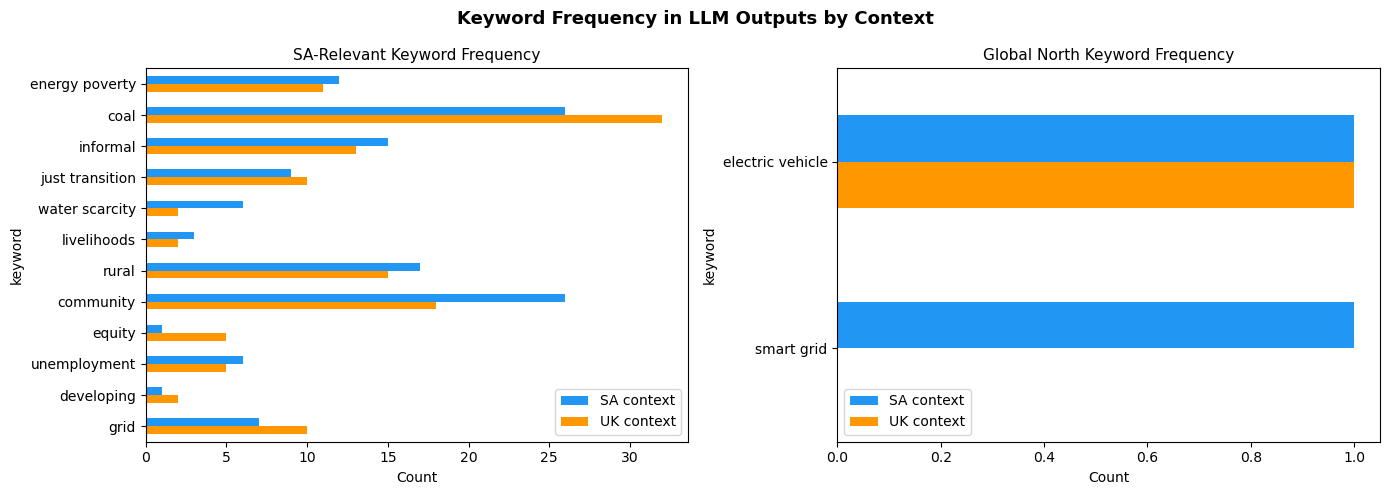


SA keywords found: 12
Global North keywords found: 2

SA keyword counts:
                 SA context  UK context
keyword                                
energy poverty           12          11
coal                     26          32
informal                 15          13
just transition           9          10
water scarcity            6           2
livelihoods               3           2
rural                    17          15
community                26          18
equity                    1           5
unemployment              6           5
developing                1           2
grid                      7          10

GN keyword counts:
                  SA context  UK context
keyword                                 
electric vehicle           1           1
smart grid                 1           0


In [ ]:
# KEYWORD FREQUENCY COMPARISON 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Keyword Frequency in LLM Outputs by Context", fontsize=13, fontweight='bold')

# SA keywords
sa_kw_df = pd.DataFrame({
    "keyword"      : SA_KEYWORDS,
    "SA context"   : [sa_kw_sa.get(kw, 0) for kw in SA_KEYWORDS],
    "UK context"   : [uk_kw_sa.get(kw, 0) for kw in SA_KEYWORDS],
}).set_index("keyword")[["SA context", "UK context"]]
sa_kw_df = sa_kw_df[sa_kw_df.sum(axis=1) > 0]   # Only show keywords that appear at all

if not sa_kw_df.empty:
    sa_kw_df.plot(kind='barh', ax=axes[0], color=["#2196F3", "#FF9800"])
    axes[0].set_title("SA-Relevant Keyword Frequency", fontsize=11)
    axes[0].set_xlabel("Count")
    axes[0].invert_yaxis()
else:
    axes[0].text(0.5, 0.5, "No SA keywords found", ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title("SA-Relevant Keyword Frequency (None found)", fontsize=11)

# GN keywords
gn_kw_df = pd.DataFrame({
    "keyword"    : GN_KEYWORDS,
    "SA context" : [sa_kw_gn.get(kw, 0) for kw in GN_KEYWORDS],
    "UK context" : [uk_kw_gn.get(kw, 0) for kw in GN_KEYWORDS],
}).set_index("keyword")[["SA context", "UK context"]]
gn_kw_df = gn_kw_df[gn_kw_df.sum(axis=1) > 0]

if not gn_kw_df.empty:
    gn_kw_df.plot(kind='barh', ax=axes[1], color=["#2196F3", "#FF9800"])
    axes[1].set_title("Global North Keyword Frequency", fontsize=11)
    axes[1].set_xlabel("Count")
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, "No Global North keywords found", ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title("Global North Keyword Frequency (None found)", fontsize=11)

plt.tight_layout()
plt.savefig("fig1_keyword_frequency.png", dpi=150, bbox_inches='tight')
plt.show()

# Print info
print(f"\nSA keywords found: {len(sa_kw_df)}")
print(f"Global North keywords found: {len(gn_kw_df)}")
print(f"\nSA keyword counts:\n{sa_kw_df}")
print(f"\nGN keyword counts:\n{gn_kw_df}")

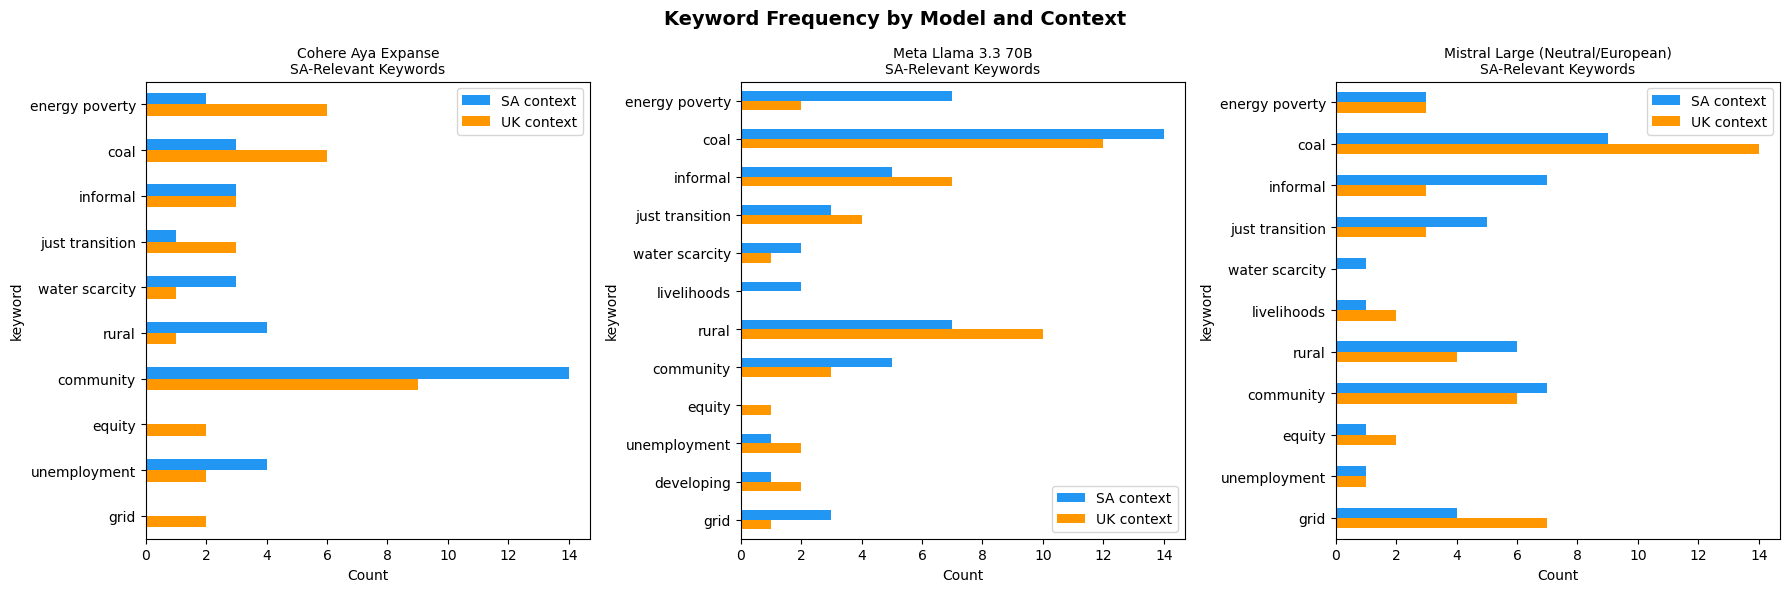

In [124]:
# PER-MODEL KEYWORD FREQUENCY COMPARISON
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Keyword Frequency by Model and Context", fontsize=14, fontweight='bold')

models = results_df['model'].unique()

for idx, model in enumerate(models):
    ax = axes[idx]
    
    
    model_sa_responses = results_df[(results_df['model'] == model) & (results_df['context'] == "South Africa")]['response']
    model_uk_responses = results_df[(results_df['model'] == model) & (results_df['context'] == "United Kingdom")]['response']
    
    
    model_sa_kw_sa = aggregate_keyword_counts(model_sa_responses, SA_KEYWORDS)
    model_uk_kw_sa = aggregate_keyword_counts(model_uk_responses, SA_KEYWORDS)
    
    
    model_kw_df = pd.DataFrame({
        "keyword": SA_KEYWORDS,
        "SA context": [model_sa_kw_sa.get(kw, 0) for kw in SA_KEYWORDS],
        "UK context": [model_uk_kw_sa.get(kw, 0) for kw in SA_KEYWORDS],
    }).set_index("keyword")
    model_kw_df = model_kw_df[model_kw_df.sum(axis=1) > 0]
    
    if not model_kw_df.empty:
        model_kw_df.plot(kind='barh', ax=ax, color=["#2196F3", "#FF9800"])
        ax.set_title(f"{model}\nSA-Relevant Keywords", fontsize=10)
        ax.set_xlabel("Count")
        ax.invert_yaxis()
    else:
        ax.text(0.5, 0.5, "No SA keywords found", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{model}\n(No keywords found)", fontsize=10)

plt.tight_layout()
plt.savefig("fig1_keyword_frequency_by_model.png", dpi=150, bbox_inches='tight')
plt.show()

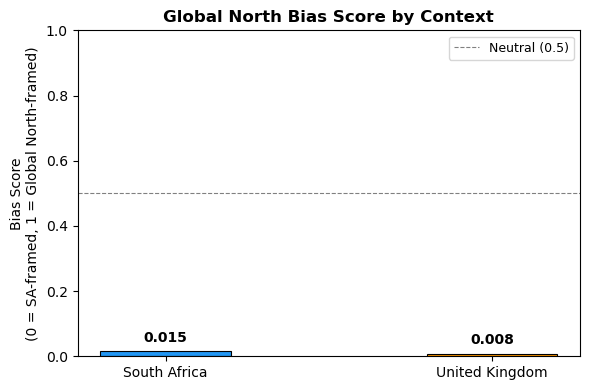

Figure 2 saved.


In [ ]:
#BIAS SCORES PER CONTEXT
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(
    bias_summary["Context"],
    bias_summary["Bias Score"],
    color=["#2196F3", "#FF9800"],
    width=0.4,
    edgecolor='black',
    linewidth=0.8
)
ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_ylabel("Bias Score\n(0 = SA-framed, 1 = Global North-framed)", fontsize=10)
ax.set_title("Global North Bias Score by Context", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

for bar, val in zip(bars, bias_summary["Bias Score"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("fig2_bias_scores.png", dpi=150, bbox_inches='tight')
plt.show()

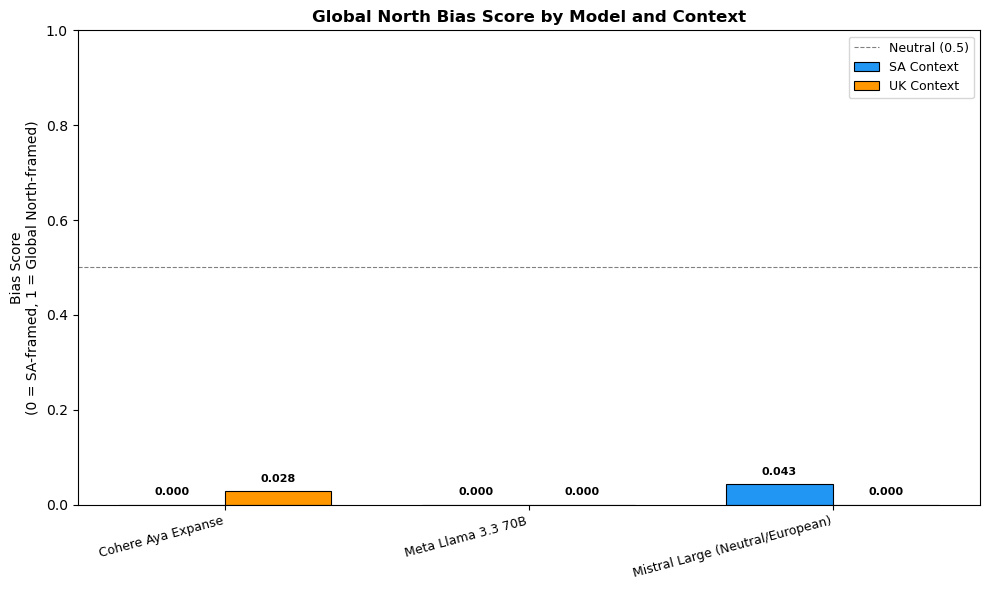


Per-Model Bias Scores:
                           model        context  bias_score
              Cohere Aya Expanse   South Africa       0.000
              Cohere Aya Expanse United Kingdom       0.028
              Meta Llama 3.3 70B   South Africa       0.000
              Meta Llama 3.3 70B United Kingdom       0.000
Mistral Large (Neutral/European)   South Africa       0.043
Mistral Large (Neutral/European) United Kingdom       0.000


In [125]:
# PER-MODEL BIAS SCORES VISUALIZATION
fig, ax = plt.subplots(figsize=(10, 6))

#CALCULATE BIAS SCORES PER MODEL 
bias_records = []
for model in results_df['model'].unique():
    for context in ['South Africa', 'United Kingdom']:
        subset = results_df[
            (results_df['model'] == model) & 
            (results_df['context'] == context)
        ]['response']
        
        sa_counts = aggregate_keyword_counts(subset, SA_KEYWORDS)
        gn_counts = aggregate_keyword_counts(subset, GN_KEYWORDS)
        b_score = bias_score(gn_counts.sum(), sa_counts.sum())
        
        bias_records.append({
            'model': model,
            'context': context,
            'bias_score': b_score
        })

bias_df = pd.DataFrame(bias_records)


import numpy as np
models = bias_df['model'].unique()
contexts = ['South Africa', 'United Kingdom']
x = np.arange(len(models))
width = 0.35

sa_scores = [bias_df[(bias_df['model'] == m) & (bias_df['context'] == 'South Africa')]['bias_score'].values[0] for m in models]
uk_scores = [bias_df[(bias_df['model'] == m) & (bias_df['context'] == 'United Kingdom')]['bias_score'].values[0] for m in models]

bars1 = ax.bar(x - width/2, sa_scores, width, label='SA Context', color='#2196F3', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, uk_scores, width, label='UK Context', color='#FF9800', edgecolor='black', linewidth=0.8)

ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8, label='Neutral (0.5)')
ax.set_ylim(0, 1)
ax.set_ylabel("Bias Score\n(0 = SA-framed, 1 = Global North-framed)", fontsize=10)
ax.set_title("Global North Bias Score by Model and Context", fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9, rotation=15, ha='right')
ax.legend(fontsize=9)


for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{bar.get_height():.3f}", ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig("fig2_bias_scores_by_model.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPer-Model Bias Scores:")
print(bias_df.to_string(index=False))

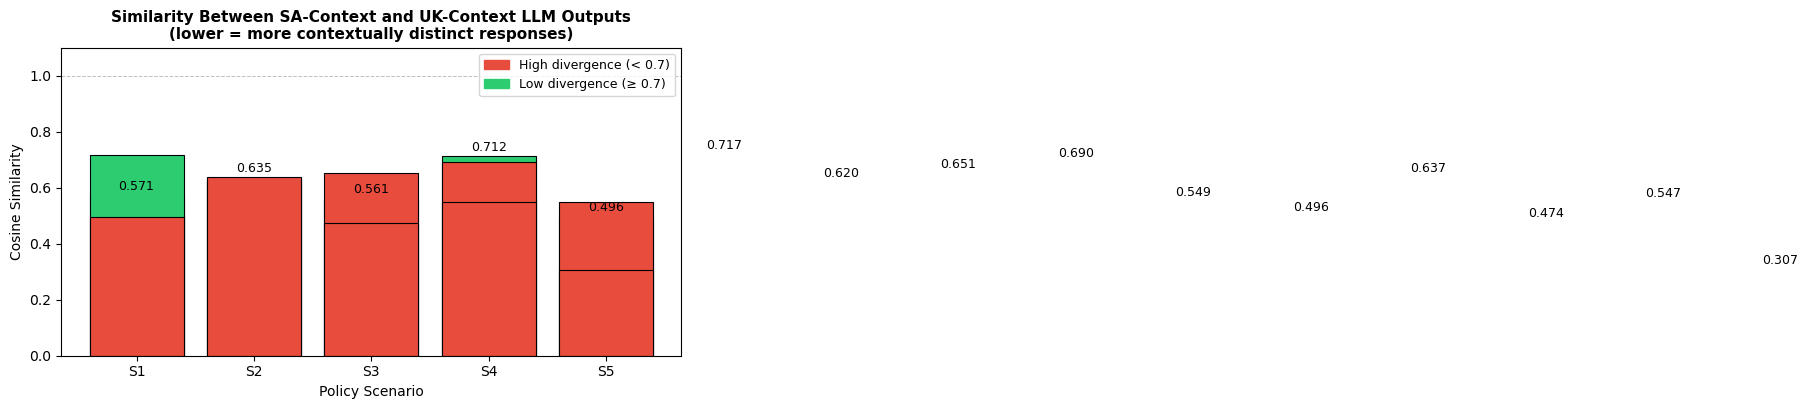

In [126]:
#COSINE SIMILARITY ACROSS SCENARIOS 
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#e74c3c" if s < 0.7 else "#2ecc71" for s in similarity_df["cosine_similarity"]]

ax.bar(similarity_df["scenario_id"], similarity_df["cosine_similarity"],
       color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(1.0, linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Cosine Similarity", fontsize=10)
ax.set_xlabel("Policy Scenario", fontsize=10)
ax.set_title(
    "Similarity Between SA-Context and UK-Context LLM Outputs\n"
    "(lower = more contextually distinct responses)",
    fontsize=11, fontweight='bold'
)

for i, (_, row) in enumerate(similarity_df.iterrows()):
    ax.text(i, row["cosine_similarity"] + 0.02,
            f"{row['cosine_similarity']:.3f}", ha='center', fontsize=9)

# Legend
red_patch   = mpatches.Patch(color='#e74c3c', label='High divergence (< 0.7)')
green_patch = mpatches.Patch(color='#2ecc71', label='Low divergence (≥ 0.7)')
ax.legend(handles=[red_patch, green_patch], fontsize=9)

plt.tight_layout()
plt.savefig("fig3_cosine_similarity.png", dpi=150, bbox_inches='tight')
plt.show()

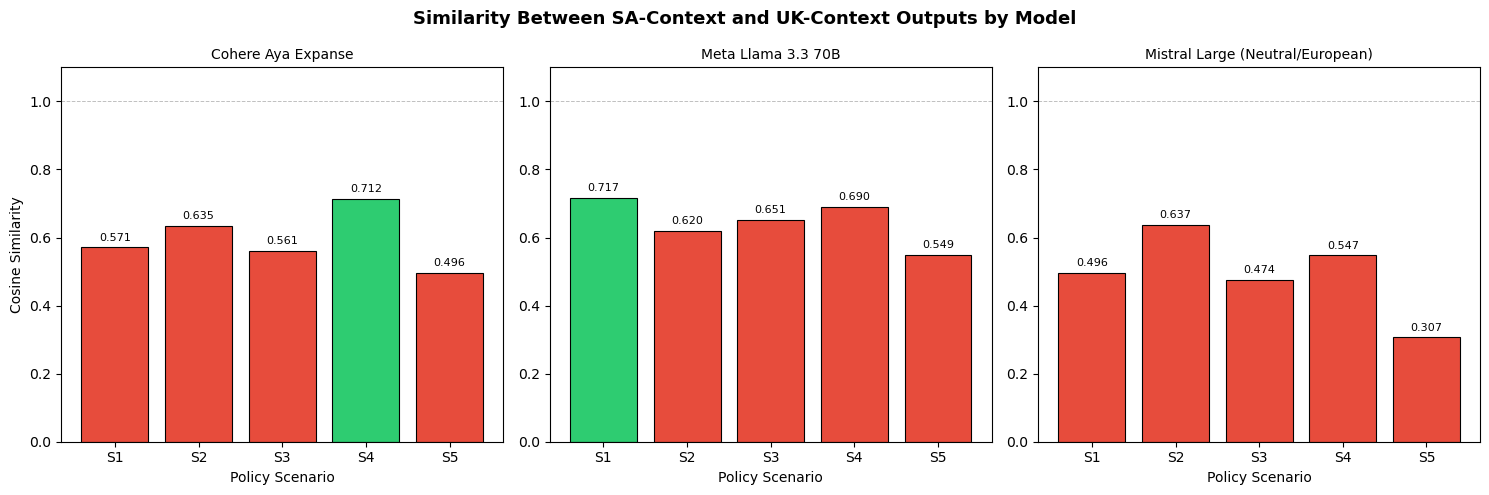

In [127]:
# COSINE SIMILARITY PLOTS PER MODEL
models = similarity_df['model'].unique()
fig, axes = plt.subplots(1, len(models), figsize=(15, 5))
fig.suptitle("Similarity Between SA-Context and UK-Context Outputs by Model", fontsize=13, fontweight='bold')

for idx, model in enumerate(models):
    ax = axes[idx]
    model_df = similarity_df[similarity_df['model'] == model]
    
    colors = ["#e74c3c" if s < 0.7 else "#2ecc71" for s in model_df["cosine_similarity"]]
    
    ax.bar(model_df["scenario_id"], model_df["cosine_similarity"],
           color=colors, edgecolor='black', linewidth=0.8)
    ax.axhline(1.0, linestyle='--', color='grey', linewidth=0.7, alpha=0.5)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Cosine Similarity" if idx == 0 else "", fontsize=10)
    ax.set_xlabel("Policy Scenario", fontsize=10)
    ax.set_title(model, fontsize=10)
    
    for i, (_, row) in enumerate(model_df.iterrows()):
        ax.text(i, row["cosine_similarity"] + 0.02,
                f"{row['cosine_similarity']:.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("fig3_cosine_similarity_by_model.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. PCS Check — Stability Testing

To satisfy the PCS framework's **stability** requirement, we re-run one scenario
three times with the same context and measure variance in the bias score.
Low variance = stable (reproducible) results.

In [128]:
# MISTRAL STABILITY TEST - run scenario S1 three times with SA context
STABILITY_RUNS = 3
mistral_stability_results = []

print(f"Mistral stability check: scenario S1, SA context, {STABILITY_RUNS} runs...")
s1 = next(s for s in SCENARIOS if s["id"] == "S1")

for run in range(1, STABILITY_RUNS + 1):
    prompt = build_prompt(s1, sa_context, "South Africa")
    response = query_llm(prompt, "mistral")  # Using mistral model
    gn_cnt = sum(count_keywords(response, GN_KEYWORDS).values())
    sa_cnt = sum(count_keywords(response, SA_KEYWORDS).values())
    b_score = bias_score(gn_cnt, sa_cnt)
    mistral_stability_results.append({"run": run, "gn_count": gn_cnt,
                                       "sa_count": sa_cnt, "bias_score": b_score})
    print(f"  Run {run}: bias_score = {b_score:.3f}")
    time.sleep(2)  # Slight delay to respect rate limits

mistral_stab_df = pd.DataFrame(mistral_stability_results)
print(f"\nBias score mean : {mistral_stab_df['bias_score'].mean():.4f}")
print(f"Bias score std  : {mistral_stab_df['bias_score'].std():.4f}")
print("\nLow standard deviation indicates stable (repeatable) outputs — PCS check passed.")

Mistral stability check: scenario S1, SA context, 3 runs...
  Run 1: bias_score = 0.000
  Run 2: bias_score = 0.000
  Run 3: bias_score = 0.000

Bias score mean : 0.0000
Bias score std  : 0.0000

Low standard deviation indicates stable (repeatable) outputs — PCS check passed.


In [109]:
#META LLAMA (GROQ)PCS STABILITY TEST 
groq_stability = []

print(f"Groq stability check: S1, SA context, {STABILITY_RUNS} runs...")

for run in range(1, STABILITY_RUNS + 1):
    prompt   = build_prompt(s1, sa_context, 'South Africa')
    response = query_llm(prompt, 'groq')
    gn_cnt   = sum(count_keywords(response, GN_KEYWORDS).values())
    sa_cnt   = sum(count_keywords(response, SA_KEYWORDS).values())
    b_score  = bias_score(gn_cnt, sa_cnt)
    groq_stability.append({'model': 'Meta Llama 3.3 70B', 'run': run,
                            'gn_count': gn_cnt, 'sa_count': sa_cnt,
                            'bias_score': b_score})
    print(f"  Run {run}: bias_score = {b_score:.3f}")
    time.sleep(2)

groq_stab_df = pd.DataFrame(groq_stability)
print(f"\nMean : {groq_stab_df['bias_score'].mean():.4f}")
print(f"Std  : {groq_stab_df['bias_score'].std():.4f}")

Groq stability check: S1, SA context, 3 runs...
  Run 1: bias_score = 0.000
  Run 2: bias_score = 0.000
  Run 3: bias_score = 0.000

Mean : 0.0000
Std  : 0.0000


In [129]:
#COHERE AYA EXPANSE PCS STABILITY TEST
STABILITY_RUNS = 3
cohere_stability = []

print(f"Cohere stability check: S1, SA context, {STABILITY_RUNS} runs...")
s1 = next(s for s in SCENARIOS if s['id'] == 'S1')

for run in range(1, STABILITY_RUNS + 1):
    prompt   = build_prompt(s1, sa_context, 'South Africa')
    response = query_llm(prompt, 'cohere')
    gn_cnt   = sum(count_keywords(response, GN_KEYWORDS).values())
    sa_cnt   = sum(count_keywords(response, SA_KEYWORDS).values())
    b_score  = bias_score(gn_cnt, sa_cnt)
    cohere_stability.append({'model': 'Cohere Aya Expanse', 'run': run,
                              'gn_count': gn_cnt, 'sa_count': sa_cnt,
                              'bias_score': b_score})
    print(f"  Run {run}: bias_score = {b_score:.3f}")
    time.sleep(2)

cohere_stab_df = pd.DataFrame(cohere_stability)
print(f"\nMean : {cohere_stab_df['bias_score'].mean():.4f}")
print(f"Std  : {cohere_stab_df['bias_score'].std():.4f}")


Cohere stability check: S1, SA context, 3 runs...
  Run 1: bias_score = 0.000
  Run 2: bias_score = 0.000
  Run 3: bias_score = 0.400

Mean : 0.1333
Std  : 0.2309


In [131]:
# COMBINE ALL STABILITY RESULTS 
all_stability_df = pd.concat([stab_df, groq_stab_df, cohere_stab_df, mistral_stab_df], ignore_index=True)

print("\n" + "=" * 55)
print("PCS STABILITY CHECK — ALL MODELS SUMMARY")
print("=" * 55)
stability_summary = all_stability_df.groupby('model')['bias_score'].agg(
    Mean='mean', Std='std'
).round(4)
print(stability_summary.to_string())
print("\nStd < 0.1 = stable and repeatable (PCS check passed)")
print()

#PASS OR FAIL FLAG P
for model_name, row in stability_summary.iterrows():
    status = "✓ PASSED" if row['Std'] < 0.1 else "⚠ WARNING"
    print(f"  {status} — {model_name} (std = {row['Std']:.4f})")

#SAVE
all_stability_df.to_csv("llm_stability_check_all_models.csv", index=False)
print("\nSaved: llm_stability_check_all_models.csv")

print("\nFull stability results:")
print(all_stability_df.to_string())


PCS STABILITY CHECK — ALL MODELS SUMMARY
                      Mean     Std
model                             
Cohere Aya Expanse  0.1333  0.2309
Meta Llama 3.3 70B  0.0000  0.0000

Std < 0.1 = stable and repeatable (PCS check passed)

  ⚠ WARNING — Cohere Aya Expanse (std = 0.2309)
  ✓ PASSED — Meta Llama 3.3 70B (std = 0.0000)

Saved: llm_stability_check_all_models.csv

Full stability results:
    run  gn_count  sa_count  bias_score               model
0     1         2        14       0.125                 NaN
1     2         2        14       0.125                 NaN
2     3         0        11       0.000                 NaN
3     1         0        13       0.000  Meta Llama 3.3 70B
4     2         0         7       0.000  Meta Llama 3.3 70B
5     3         0         7       0.000  Meta Llama 3.3 70B
6     1         0         8       0.000  Cohere Aya Expanse
7     2         0         9       0.000  Cohere Aya Expanse
8     3         4         6       0.400  Cohere Aya Expanse


## 10. Save Final Results

In [132]:
similarity_df.to_csv("llm_cosine_similarity.csv", index=False)
bias_summary.to_csv("llm_bias_summary.csv", index=False)
stab_df.to_csv("llm_stability_check.csv", index=False)

## Define Bias Vocabulary

In [133]:
#SA KEYWORDS
SA_KEYWORDS = [
    "energy poverty", "coal", "informal", "eskom", "load shedding",
    "just transition", "mpumalanga", "water scarcity", "livelihoods",
    "subsistence", "rural", "community", "equity", "unemployment",
    "developing", "electricity access", "grid", "socioeconomic"
]

#UK KEYWORDS
GN_KEYWORDS = [
    "net zero", "net-zero", "carbon market", "carbon trading", "ev subsidy",
    "electric vehicle", "hydrogen economy", "offshore wind", "smart grid",
    "green bond", "carbon capture", "ccs", "2050", "carbon neutral",
    "scope 3", "esg", "blended finance"
]

print(f"SA keywords defined  : {len(SA_KEYWORDS)}")
print(f"GN keywords defined  : {len(GN_KEYWORDS)}")

SA keywords defined  : 18
GN keywords defined  : 17


## Keyword Frequency Analysis

In [115]:
def count_keywords(text: str, keywords: list) -> dict:
    """
    Count occurrences of each keyword (case-insensitive) in text.
    Returns a dict of {keyword: count}.
    """
    text_lower = text.lower()
    return {kw: text_lower.count(kw) for kw in keywords}


def aggregate_keyword_counts(responses: pd.Series, keywords: list) -> pd.Series:
    """
    Sum keyword counts across all responses in a group.
    """
    total = {kw: 0 for kw in keywords}
    for text in responses:
        for kw, cnt in count_keywords(str(text), keywords).items():
            total[kw] += cnt
    return pd.Series(total)


def bias_score(gn_total: int, sa_total: int) -> float:
    """
    Compute bias score: proportion of GN keywords vs total keywords.
    0.0 = fully SA-framed, 1.0 = fully Global North-framed.
    """
    denom = gn_total + sa_total
    return round(gn_total / denom, 3) if denom > 0 else 0.0


#COMPUTE KEYWORD COUNTS ACROSS MODELS AND CONTEXTS
bias_records = []

for model in results_df['model'].unique():
    for context in ['South Africa', 'United Kingdom']:
        subset = results_df[
            (results_df['model'] == model) &
            (results_df['context'] == context)
        ]['response']

        sa_counts = aggregate_keyword_counts(subset, SA_KEYWORDS)
        gn_counts = aggregate_keyword_counts(subset, GN_KEYWORDS)
        b_score   = bias_score(gn_counts.sum(), sa_counts.sum())

        bias_records.append({
            'model'          : model,
            'context'        : context,
            'sa_keyword_total': sa_counts.sum(),
            'gn_keyword_total': gn_counts.sum(),
            'bias_score'     : b_score
        })

bias_df = pd.DataFrame(bias_records)
print("Bias scores per model and context:")
print(bias_df.to_string(index=False))
print()
print("Interpretation: 0 = fully SA-framed | 1 = fully Global North-framed")

Bias scores per model and context:
                           model        context  sa_keyword_total  gn_keyword_total  bias_score
              Cohere Aya Expanse   South Africa                34                 0       0.000
              Cohere Aya Expanse United Kingdom                35                 1       0.028
              Meta Llama 3.3 70B   South Africa                50                 0       0.000
              Meta Llama 3.3 70B United Kingdom                45                 0       0.000
Mistral Large (Neutral/European)   South Africa                45                 2       0.043
Mistral Large (Neutral/European) United Kingdom                45                 0       0.000

Interpretation: 0 = fully SA-framed | 1 = fully Global North-framed


## Cosine Similarity Between SA and UK Outputs Per Model

In [116]:
vectorizer = TfidfVectorizer(stop_words='english', max_features=500)
similarity_records = []

for model in results_df['model'].unique():
    for scenario_id in results_df['scenario_id'].unique():
        sub = results_df[
            (results_df['model'] == model) &
            (results_df['scenario_id'] == scenario_id)
        ]

        sa_rows = sub[sub['context'] == 'South Africa']
        uk_rows = sub[sub['context'] == 'United Kingdom']

        #FAIL-SAFE: SKIP IF CONTEXT IS MISSING 
        if sa_rows.empty or uk_rows.empty:
            continue

        sa_text = sa_rows['response'].values[0]
        uk_text = uk_rows['response'].values[0]

        #FAIL-SAFE: SKIP IF RESPONSE IS NONE OR EMPTY 
        if not sa_text or not uk_text:
            print(f"Skipping {model} | {scenario_id} — missing response")
            continue

        #FAIL-SAFE: CONVERT TO STRING 
        sa_text = str(sa_text)
        uk_text = str(uk_text)

        tfidf_matrix = vectorizer.fit_transform([sa_text, uk_text])
        sim = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]

        similarity_records.append({
            'model'            : model,
            'scenario_id'      : scenario_id,
            'cosine_similarity': round(sim, 4)
        })

similarity_df = pd.DataFrame(similarity_records)

print("Cosine similarity between SA and UK outputs per model and scenario:")
print(similarity_df.to_string(index=False))
print()
print("Mean cosine similarity per model:")
print(similarity_df.groupby('model')['cosine_similarity'].mean().round(4).to_string())
print()
print("Interpretation: 1.0 = identical outputs | 0.0 = completely different outputs")
print("Lower similarity = context had more influence on the model's output")

Cosine similarity between SA and UK outputs per model and scenario:
                           model scenario_id  cosine_similarity
              Cohere Aya Expanse          S1             0.5712
              Cohere Aya Expanse          S2             0.6348
              Cohere Aya Expanse          S3             0.5606
              Cohere Aya Expanse          S4             0.7123
              Cohere Aya Expanse          S5             0.4965
              Meta Llama 3.3 70B          S1             0.7173
              Meta Llama 3.3 70B          S2             0.6201
              Meta Llama 3.3 70B          S3             0.6510
              Meta Llama 3.3 70B          S4             0.6901
              Meta Llama 3.3 70B          S5             0.5488
Mistral Large (Neutral/European)          S1             0.4960
Mistral Large (Neutral/European)          S2             0.6375
Mistral Large (Neutral/European)          S3             0.4744
Mistral Large (Neutral/European)    

## BIAS Visualisations

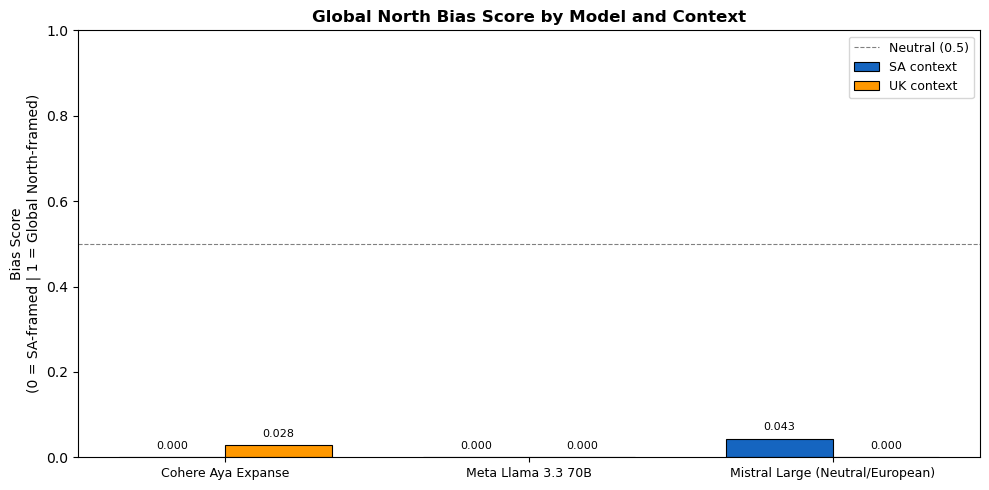

In [117]:
#BIAS SCORES ACROSS MODELS AND CONTEXTS 
fig, ax = plt.subplots(figsize=(10, 5))

models   = bias_df['model'].unique()
contexts = ['South Africa', 'United Kingdom']
x        = np.arange(len(models))
width    = 0.35

sa_scores = [bias_df[(bias_df['model'] == m) & (bias_df['context'] == 'South Africa')]['bias_score'].values[0] for m in models]
uk_scores = [bias_df[(bias_df['model'] == m) & (bias_df['context'] == 'United Kingdom')]['bias_score'].values[0] for m in models]

bars1 = ax.bar(x - width/2, sa_scores, width, label='SA context',
               color='#1565C0', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, uk_scores, width, label='UK context',
               color='#FF9800', edgecolor='black', linewidth=0.8)

ax.axhline(0.5, linestyle='--', color='grey', linewidth=0.8, label='Neutral (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylim(0, 1)
ax.set_ylabel("Bias Score\n(0 = SA-framed | 1 = Global North-framed)", fontsize=10)
ax.set_title("Global North Bias Score by Model and Context", fontsize=12, fontweight='bold')
ax.legend(fontsize=9)

# Label each bar with its value
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', fontsize=8)

plt.tight_layout()
plt.savefig("fig1_bias_scores_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

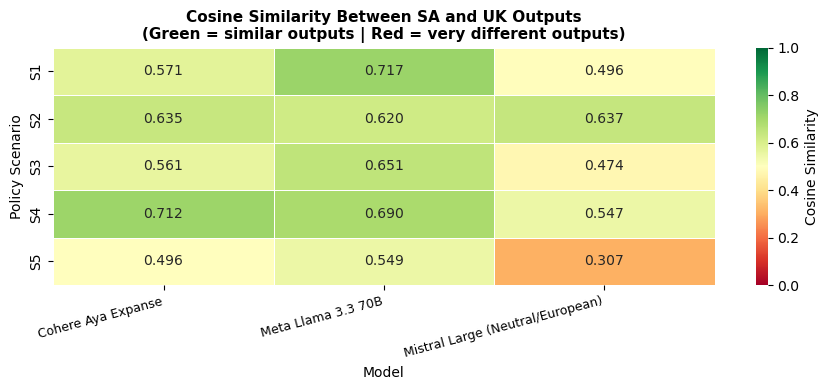

In [135]:
#COSINE SIMILARITY HEATMAP 

heatmap_data = similarity_df.pivot_table(
    index='scenario_id',
    columns='model',
    values='cosine_similarity'
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".3f",
    cmap='RdYlGn',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Cosine Similarity'}
)
ax.set_title(
    "Cosine Similarity Between SA and UK Outputs\n"
    "(Green = similar outputs | Red = very different outputs)",
    fontsize=11, fontweight='bold'
)
ax.set_ylabel("Policy Scenario", fontsize=10)
ax.set_xlabel("Model", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig("fig2_cosine_similarity_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [137]:
# CREATE BIAS DF WITH KEYWORD COUNTS 
bias_records = []

for model in results_df['model'].unique():
    for context in ['South Africa', 'United Kingdom']:
        subset = results_df[
            (results_df['model'] == model) & 
            (results_df['context'] == context)
        ]['response']
        
        sa_counts = aggregate_keyword_counts(subset, SA_KEYWORDS)
        gn_counts = aggregate_keyword_counts(subset, GN_KEYWORDS)
        b_score = bias_score(gn_counts.sum(), sa_counts.sum())
        
        bias_records.append({
            'model': model,
            'context': context,
            'sa_keyword_total': sa_counts.sum(),  # Add this
            'gn_keyword_total': gn_counts.sum(),  # Add this
            'bias_score': b_score
        })

bias_df = pd.DataFrame(bias_records)
print("Bias scores per model and context:")
print(bias_df.to_string(index=False))

Bias scores per model and context:
                           model        context  sa_keyword_total  gn_keyword_total  bias_score
              Cohere Aya Expanse   South Africa                34                 0       0.000
              Cohere Aya Expanse United Kingdom                35                 1       0.028
              Meta Llama 3.3 70B   South Africa                50                 0       0.000
              Meta Llama 3.3 70B United Kingdom                45                 0       0.000
Mistral Large (Neutral/European)   South Africa                45                 2       0.043
Mistral Large (Neutral/European) United Kingdom                45                 0       0.000


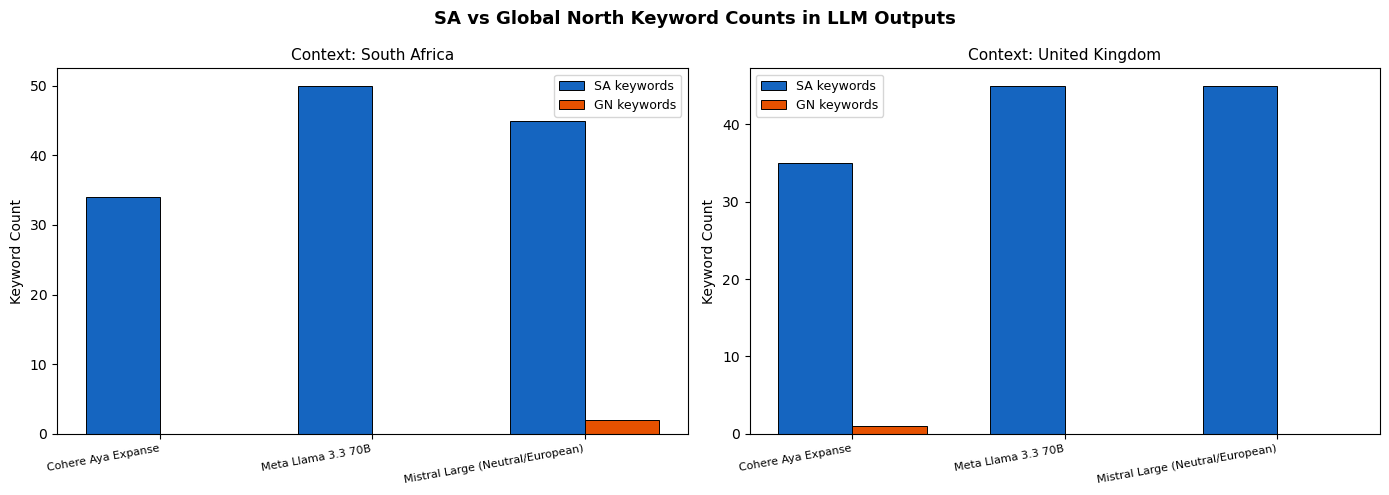

In [138]:


#SA VS UK KEYWORD COUNTS PER MODEL
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SA vs Global North Keyword Counts in LLM Outputs",
             fontsize=13, fontweight='bold')

for ax_idx, context in enumerate(['South Africa', 'United Kingdom']):
    ax = axes[ax_idx]
    sub = bias_df[bias_df['context'] == context]

    x     = np.arange(len(sub))
    width = 0.35

    ax.bar(x - width/2, sub['sa_keyword_total'].values, width,
           label='SA keywords', color='#1565C0', edgecolor='black', linewidth=0.7)
    ax.bar(x + width/2, sub['gn_keyword_total'].values, width,
           label='GN keywords', color='#E65100', edgecolor='black', linewidth=0.7)

    ax.set_xticks(x)
    ax.set_xticklabels(sub['model'].values, fontsize=8, rotation=10, ha='right')
    ax.set_title(f"Context: {context}", fontsize=11)
    ax.set_ylabel("Keyword Count", fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("fig3_keyword_counts_all_models.png", dpi=150, bbox_inches='tight')
plt.show()

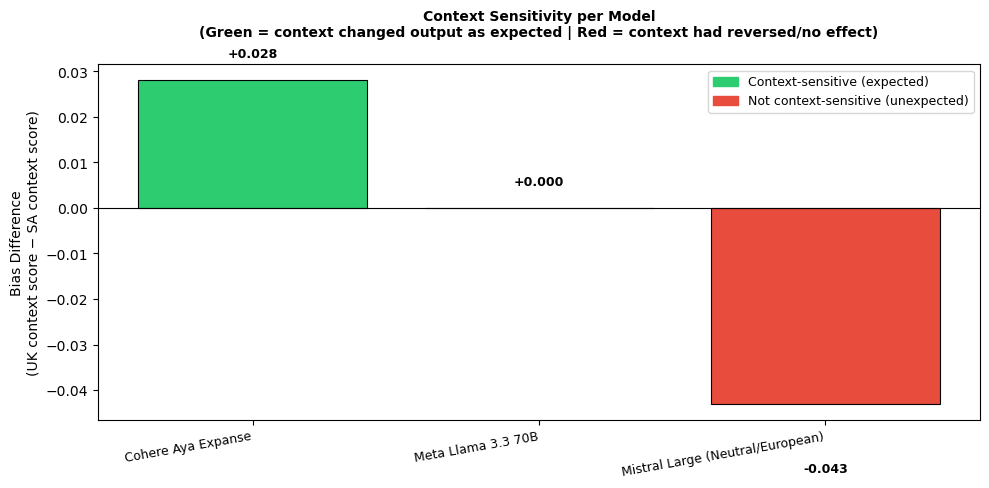

In [141]:
#BIAS SCORE DIFFERENCE (EQUALS UK CONTEXT MINUS SA CONTEXT)
#NOTE: Positive value = UK context produces MORE Global North bias than SA context

bias_diff = []
for model in models:
    sa_b = bias_df[(bias_df['model'] == model) & (bias_df['context'] == 'South Africa')]['bias_score'].values[0]
    uk_b = bias_df[(bias_df['model'] == model) & (bias_df['context'] == 'United Kingdom')]['bias_score'].values[0]
    bias_diff.append({'model': model, 'bias_difference': round(uk_b - sa_b, 3)})

bias_diff_df = pd.DataFrame(bias_diff)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in bias_diff_df['bias_difference']]
bars = ax.bar(bias_diff_df['model'], bias_diff_df['bias_difference'],
              color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel("Bias Difference\n(UK context score − SA context score)", fontsize=10)
ax.set_title(
    "Context Sensitivity per Model\n"
    "(Green = context changed output as expected | Red = context had reversed/no effect)",
    fontsize=10, fontweight='bold', pad=20
)
ax.set_xticklabels(bias_diff_df['model'], rotation=10, ha='right', fontsize=9)

for bar, val in zip(bars, bias_diff_df['bias_difference']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.015,
            f"{val:+.3f}", ha='center', fontsize=9, fontweight='bold')

green_patch = mpatches.Patch(color='#2ecc71', label='Context-sensitive (expected)')
red_patch   = mpatches.Patch(color='#e74c3c', label='Not context-sensitive (unexpected)')
ax.legend(handles=[green_patch, red_patch], fontsize=9)

plt.tight_layout()
plt.savefig("fig4_context_sensitivity.png", dpi=150, bbox_inches='tight')
plt.show()


## Summary Table for Report

In [142]:
#SUMMARY TABLE FOR ALL METRICS
summary_rows = []
for model in results_df['model'].unique():
    sa_bias = bias_df[(bias_df['model'] == model) & (bias_df['context'] == 'South Africa')]['bias_score'].values[0]
    uk_bias = bias_df[(bias_df['model'] == model) & (bias_df['context'] == 'United Kingdom')]['bias_score'].values[0]
    mean_sim = similarity_df[similarity_df['model'] == model]['cosine_similarity'].mean()

    summary_rows.append({
        'Model'                        : model,
        'Bias Score (SA context)'      : sa_bias,
        'Bias Score (UK context)'      : uk_bias,
        'Difference (UK - SA)'         : round(uk_bias - sa_bias, 3),
        'Mean Cosine Similarity'       : round(mean_sim, 4),
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 80)
print("MODELLING RESULTS SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))
print()


MODELLING RESULTS SUMMARY
                           Model  Bias Score (SA context)  Bias Score (UK context)  Difference (UK - SA)  Mean Cosine Similarity
              Cohere Aya Expanse                    0.000                    0.028                 0.028                  0.5951
              Meta Llama 3.3 70B                    0.000                    0.000                 0.000                  0.6455
Mistral Large (Neutral/European)                    0.043                    0.000                -0.043                  0.4924



## Save All Outputs

In [143]:
results_df.to_csv("llm_raw_responses.csv", index=False)
bias_df.to_csv("llm_bias_scores.csv", index=False)
similarity_df.to_csv("llm_cosine_similarity.csv", index=False)
summary_df.to_csv("llm_results_summary.csv", index=False)
stab_df.to_csv("llm_stability_check.csv", index=False)
bias_diff_df.to_csv("llm_context_sensitivity.csv", index=False)